# Homework5: Exploration of Heart Disease Data (Use UCI Dataset)
## Part 1: Confidence Intervals for a Personalized Subgroup
    1. Define a subgroup of patients based on age, sex, chest pain type, or another variable of your choice.
    2. For this subgroup:
        - Randomly select three different sample sizes (e.g., small, medium, large).
        - Calculate the proportion of patients with heart disease.
        - Construct 95% confidence intervals.
    3. Questions:
        - How does interval width change with sample size?
        - Compare your subgroup’s proportion to the overall population.
        - Write 2–3 sentences explaining why your subgroup may differ from the population.
        
## Part 2: Hypothesis Tests 

### Choose two tests that were not done in class. For each:

    - State your research question and define your null and alternative hypotheses.
    - Select an appropriate test (two-proportion, one-sample t-test, two-sample t-test).
    - Compute the test and report the statistic and p-value.
    - Visualize the data appropriately (bar chart, histogram, or boxplot).
    - Write 2–3 sentences interpreting your results.
    
## Part 3: Type I and Type II Errors
### For one of your tests above, describe:
    - What a Type I error would mean in your context.
    - What a Type II error would mean.
    - Explain which error would be more critical for patient care or medical research.

## Part 4: Sample Size and Power Planning
    - Pick one of your tests.
    - Assume α = 0.05 and desired power between 0.8–0.9.
    - Estimate effect size from your data or justify a hypothetical one.
    - Compute the required sample size.
    - Optional: Generate a power curve showing power vs sample size for your chosen effect size.
    - Write 2–3 sentences interpreting how sample size, effect size, and power interact.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint, proportions_ztest, proportion_effectsize
from scipy import stats
from statsmodels.stats.power import NormalIndPower, TTestIndPower, TTestPower

In [17]:
df = pd.read_csv("Heardisease.csv")

df.head(n = 10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1,1


## Part 1 Response:

Research Qustion: Is the regular blood for adults older than 65 greater than the medical average?
Null = Not significantly different in adults above 65
Alternative = Significantly different in adults above 65

In [28]:
sbgp = df[df['trestbps'] < 140.0]

sample_sizes = [5,25,50]
ci_results = []

def sample_ci(df, n, alpha=0.05):
    sample = df.sample(n, random_state=42)
    x = sample['heart_disease'].sum()
    p_hat = x / n
    ci_low, ci_upp = proportion_confint(count=x, nobs=n, alpha=alpha, method='wilson')
    return p_hat, ci_low, ci_upp

for n in sample_sizes:
    p_hat, low, up = sample_ci(df, n)
    ci_results.append({'n': n, 'proportion': p_hat, 'CI_low': low, 'CI_high': up, 'width': up-low})


ci_df = pd.DataFrame(ci_results)
ci_df

,n,proportion,CI_low,CI_high,width
0,5,0.40,0.117621,0.769276,0.651655
1,25,0.36,0.202479,0.554815,0.352336
2,50,0.38,0.258628,0.518496,0.259868


1. The interval width decreases with the population, as it is seen decreasing greatly with 5 and 25. As it get's bigger, the width decreases at a shorter length.
2. The proortion of the popoulation is greater than the sample sizes at 0.46, compared to 0.40, 0.36, and 0.38.
3. My subgroup differs from the populations because it controls for regular heart rate, compared to the numerous greater heart rates found in the dataset. This creates a stark contrast in impact on the 'trestbps' for the proportions.

In [27]:
proportion = df['heart_disease'].mean()
proportion

np.float64(0.4612794612794613)

## Part 2 Response:

In [29]:
mean = df['trestbps'].mean()
mean

np.float64(131.69360269360268)

In [37]:
sbgp2 = df[df['age'] > 65]

mu0 = 132
t_stat, p_value = stats.ttest_1samp(sbgp2['trestbps'], mu0)
print("P-Valudfe and Test Statistic:")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.2f}")
print("P-value is greater than statistical significance of 0.05. Do not reject null hypothesis.")

P-Value and Test Statistic:
t-statistic = 1.455
p-value = 0.16
P-value is greater than statistical significance of 0.05. Do not reject null hypothesis.


{'whiskers': [<matplotlib.lines.Line2D at 0x16c58e0d0>,
 'caps': [<matplotlib.lines.Line2D at 0x16c58e350>,
 'boxes': [<matplotlib.lines.Line2D at 0x16c4fdf90>],
 'medians': [<matplotlib.lines.Line2D at 0x16c58e5d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x16c58e710>],
 'means': []}

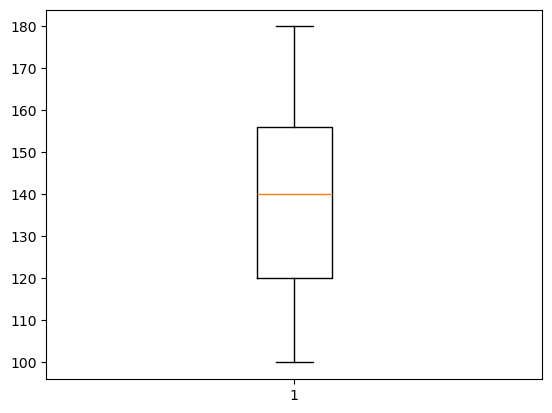

In [38]:
plt.boxplot(sbgp2['trestbps'])

My results showed that there wasn't a significant enough different in the resting blood pressure of adults above 65 compared to the average. While the t-statistic was far from the mean resting blood pressure, the p-value was too large for a conclusion. 

## Part 3 Response:

1. Type 1 Error would be falsely stating that the blood pressure was different than the average, when it's normal.
2. Type 2 Error would be falsely stating that your blood pressure is normal, when it is significantly different from the average.
3. A type 2 error would be more critical, as you would be assuming your healthy when your body isn't. Investigating a false medical issue wouldn't have much negative effect, but ignoring a real one could be life-ending. 

## Part 4 Responses:

In [45]:

sbgpmean = sbgp['trestbps'].mean()
sbgpstd = sbgp['trestbps'].std()
# 140 - 132 = 8, so i went with that for hypothetical difference

mu1 = mu0 + 8
estimated_effect_size = (mu1 - mu0)/ sbgpstd
estimated_effect_size

T_test = TTestPower()
Part_4 = T_test.solve_power(effect_size=estimated_effect_size, alpha = 0.05, power = 0.9, alternative = 'two-sided')
print(Part_4)

18.57621766040958


The sample size required here would be 19, as you can't have half a person. The effect size, and power all impact how the  sample size is computed. The greater the power, the greater the other two values would need to be for a correct analysis as the power increases the correct sample size probability.  